# Scraping books.toscrape.com

We're scraping all 1,000 books from [books.toscrape.com](https://books.toscrape.com/)

The approach: **get one book working first, then scale up.


---
## Step 1 — Setup

In [2]:
!pip install requests

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\asharma9\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!pip install beautifulsoup4

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\asharma9\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:


import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

imports ok


---
## Step 2 — Download one page

In [6]:
url = "https://books.toscrape.com/catalogue/page-1.html"

response = requests.get(url)
response.encoding = "utf-8" 

print(response.status_code)

200


HTML to BeautifulSoup, which turns text into something we can search through.

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

# print the first 1000 characters just to confirm we got real HTML
print(response.text[:1000])



<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
        <meta name="created" content="24th Jun 2016 09:30" />
        <meta name="description" content="" />
        <meta name="viewport" content="width=device-width" />
        <meta name="robots" content="NOARCHIVE,NOCACHE" />

        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
        <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->

        
            <link rel="shortcut icon" href="../static/oscar/fav

---
## Step 3 — Find the books

In [8]:
books = soup.select("article.product_pod")

print(f"found {len(books)} books on this page")

found 20 books on this page


In [9]:
first = books[0]

print(first.prettify())

<article class="product_pod">
 <div class="image_container">
  <a href="a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="../media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   £51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



---
## Step 4 — Extract every field from ONE book

In [ ]:
link = first.select_one("h3 a")  

print("visible text: ", link.text)
print("title attribute:", link["title"])

visible text:  A Light in the ...
title attribute: A Light in the Attic


In [11]:
price_text = first.select_one("p.price_color").text
print("raw:", price_text)

price = float(re.search(r"[\d.]+", price_text).group())
print("as number:", price)

raw: £51.77
as number: 51.77


In [12]:
rating_tag = first.select_one("p.star-rating")

print("classes on this tag:", rating_tag["class"])

classes on this tag: ['star-rating', 'Three']


In [13]:
RATINGS = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

rating = None
for css_class in rating_tag["class"]:
    if css_class in RATINGS:
        rating = RATINGS[css_class]

print("rating:", rating)

rating: 3


### Stock status and the link

In [14]:
availability = first.select_one("p.instock.availability").text
in_stock = "In stock" in availability

# href is relative, like "a-light-in-the-attic_1000/index.html"
# so we stick the base URL on the front to make it usable
book_url = "https://books.toscrape.com/catalogue/" + link["href"]

print("in stock:", in_stock)
print("url:", book_url)

in stock: True
url: https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


### Put it together in a dictionary


In [15]:
one_book = {
    "title": link["title"],
    "price": price,
    "rating": rating,
    "in_stock": in_stock,
    "url": book_url,
}

one_book

{'title': 'A Light in the Attic',
 'price': 51.77,
 'rating': 3,
 'in_stock': True,
 'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}

---
## Step 5 — Loop over all 20 books on this page

In [16]:
def parse_book(pod):
    """Take one <article class="product_pod"> and return a dictionary."""
    link = pod.select_one("h3 a")

    price_text = pod.select_one("p.price_color").text
    price = float(re.search(r"[\d.]+", price_text).group())

    rating = None
    for css_class in pod.select_one("p.star-rating")["class"]:
        if css_class in RATINGS:
            rating = RATINGS[css_class]

    availability = pod.select_one("p.instock.availability").text

    return {
        "title": link["title"],
        "price": price,
        "rating": rating,
        "in_stock": "In stock" in availability,
        "url": "https://books.toscrape.com/catalogue/" + link["href"],
    }


# test it on the page we already downloaded
page_one = [parse_book(pod) for pod in books]

print(f"{len(page_one)} books")
page_one[:3]

20 books


[{'title': 'A Light in the Attic',
  'price': 51.77,
  'rating': 3,
  'in_stock': True,
  'url': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'},
 {'title': 'Tipping the Velvet',
  'price': 53.74,
  'rating': 1,
  'in_stock': True,
  'url': 'https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html'},
 {'title': 'Soumission',
  'price': 50.1,
  'rating': 1,
  'in_stock': True,
  'url': 'https://books.toscrape.com/catalogue/soumission_998/index.html'}]

---
## Step 6 — Loop over all 50 pages

The URLs are predictable:

```
.../catalogue/page-1.html
.../catalogue/page-2.html
...
.../catalogue/page-50.html
```

Two things

- **`time.sleep(0.5)`** — half a second between requests. 
- **`if response.status_code != 200: break`** — stop when we run off the end,
  rather than hardcoding 50. If the site grows, the scraper still works.


In [17]:
all_books = []
page = 1

while True:
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)

    if response.status_code != 200:
        print(f"page {page} returned {response.status_code} - stopping")
        break

    response.encoding = "utf-8"
    soup = BeautifulSoup(response.text, "html.parser")

    pods = soup.select("article.product_pod")
    if not pods:
        break

    for pod in pods:
        all_books.append(parse_book(pod))

    print(f"page {page}: {len(pods)} books (running total {len(all_books)})")

    page += 1
    time.sleep(0.5)

print(f"\nDONE - {len(all_books)} books total")

page 1: 20 books (running total 20)
page 2: 20 books (running total 40)
page 3: 20 books (running total 60)
page 4: 20 books (running total 80)
page 5: 20 books (running total 100)
page 6: 20 books (running total 120)
page 7: 20 books (running total 140)
page 8: 20 books (running total 160)
page 9: 20 books (running total 180)
page 10: 20 books (running total 200)
page 11: 20 books (running total 220)
page 12: 20 books (running total 240)
page 13: 20 books (running total 260)
page 14: 20 books (running total 280)
page 15: 20 books (running total 300)
page 16: 20 books (running total 320)
page 17: 20 books (running total 340)
page 18: 20 books (running total 360)
page 19: 20 books (running total 380)
page 20: 20 books (running total 400)
page 21: 20 books (running total 420)
page 22: 20 books (running total 440)
page 23: 20 books (running total 460)
page 24: 20 books (running total 480)
page 25: 20 books (running total 500)
page 26: 20 books (running total 520)
page 27: 20 books (runnin

---
## Step 7 — Load into pandas

In [18]:
df = pd.DataFrame(all_books)

df.head()

,title,price,rating,in_stock,url
0,A Light in the Attic,51.77,3,True,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,True,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,True,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,True,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,True,https://books.toscrape.com/catalogue/sapiens-a...


In [ ]:
print(df.shape)     
df.info()

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   title     1000 non-null   object 
 1   price     1000 non-null   float64
 2   rating    1000 non-null   int64  
 3   in_stock  1000 non-null   bool   
 4   url       1000 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 32.4+ KB


In [20]:
df.isnull().sum()

title       0
price       0
rating      0
in_stock    0
url         0
dtype: int64

In [ ]:
df.to_csv("books.csv", index=False)

print("saved books.csv")

---
## Step 9 — Categories (the interesting part)

**genre**. It isn't on the listing pages
at all — it only exists on each book's own page, in the breadcrumb:

```
Home > Books > Poetry > A Light in the Attic
```

In [22]:
test_url = df.loc[0, "url"]

response = requests.get(test_url)
response.encoding = "utf-8"
book_soup = BeautifulSoup(response.text, "html.parser")

crumbs = book_soup.select("ul.breadcrumb li")

for c in crumbs:
    print(repr(c.text.strip()))

'Home'
'Books'
'Poetry'
'A Light in the Attic'


The category is the **second-to-last** crumb — index `[-2]`.

In [ ]:
def parse_detail(url):
    """Fetch one book's page, return the extra fields."""
    response = requests.get(url)
    response.encoding = "utf-8"
    soup = BeautifulSoup(response.text, "html.parser")

    crumbs = soup.select("ul.breadcrumb li")
    category = crumbs[-2].text.strip()

    table = {}
    for row in soup.select("table tr"):
        th, td = row.find("th"), row.find("td")
        if th and td:
            table[th.text.strip()] = td.text.strip()

    stock_match = re.search(r"(\d+) available", table.get("Availability", ""))

    return {
        "category": category,
        "upc": table.get("UPC"),
        "stock_count": int(stock_match.group(1)) if stock_match else None,
        "review_count": int(table.get("Number of reviews", 0)),
    }


parse_detail(test_url)

{'category': 'Poetry',
 'upc': 'a897fe39b1053632',
 'stock_count': 22,
 'review_count': 0}

In [25]:
details = []

for i, url in enumerate(df["url"], start=1):
    try:
        details.append(parse_detail(url))
    except Exception as err:
        print(f"  ! book {i} failed: {err}")
        details.append({})

    if i % 100 == 0:
        print(f"{i}/{len(df)}")

    time.sleep(0.5)

print("done")

100/1000
  ! book 140 failed: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
200/1000
300/1000
400/1000
500/1000
600/1000
700/1000
800/1000
900/1000
  ! book 945 failed: ('Connection broken: IncompleteRead(12047 bytes read, 7291 more expected)', IncompleteRead(12047 bytes read, 7291 more expected))
1000/1000
done


In [26]:
# glue the new columns onto the original DataFrame
details_df = pd.DataFrame(details)
full = pd.concat([df, details_df], axis=1)

full.to_csv("books_full.csv", index=False)

print(full.shape)
full.head()

(1000, 9)


,title,price,rating,in_stock,url,category,upc,stock_count,review_count
0,A Light in the Attic,51.77,3,True,https://books.toscrape.com/catalogue/a-light-i...,Poetry,a897fe39b1053632,22.0,0.0
1,Tipping the Velvet,53.74,1,True,https://books.toscrape.com/catalogue/tipping-t...,Historical Fiction,90fa61229261140a,20.0,0.0
2,Soumission,50.10,1,True,https://books.toscrape.com/catalogue/soumissio...,Fiction,6957f44c3847a760,20.0,0.0
3,Sharp Objects,47.82,4,True,https://books.toscrape.com/catalogue/sharp-obj...,Mystery,e00eb4fd7b871a48,20.0,0.0
4,Sapiens: A Brief History of Humankind,54.23,5,True,https://books.toscrape.com/catalogue/sapiens-a...,History,4165285e1663650f,20.0,0.0


---
## Step 10 — Data Look

In [27]:
# how many books per genre?
full["category"].value_counts().head(15)

category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     25
Poetry                 19
Classics               19
History                18
Name: count, dtype: int64

In [28]:
# average price by genre, only genres with enough books to mean anything
by_genre = (full.groupby("category")
                .agg(avg_price=("price", "mean"),
                     avg_rating=("rating", "mean"),
                     n=("title", "count"))
                .query("n >= 10")
                .sort_values("avg_price", ascending=False))

by_genre

,avg_price,avg_rating,n
category,,,
Travel,39.794545,2.727273,11
Fantasy,39.593958,3.083333,48
History,37.295000,2.944444,18
Womens Fiction,36.791176,3.117647,17
Classics,36.545263,2.473684,19
Fiction,36.066615,3.184615,65
Poetry,35.974211,3.526316,19
Horror,35.949412,2.705882,17
Add a comment,35.796418,2.761194,67


In [ ]:
full.groupby("rating")["price"].mean()

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64

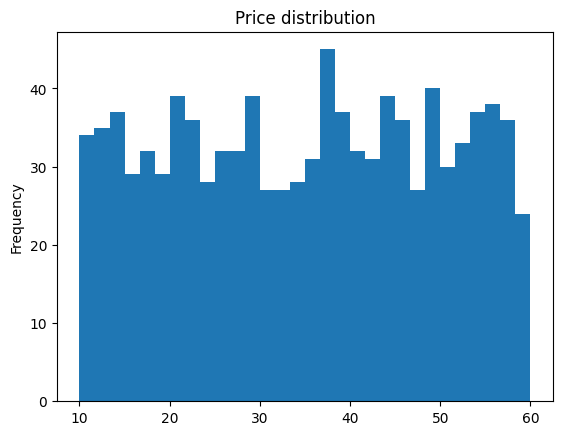

In [30]:
full["price"].plot(kind="hist", bins=30, title="Price distribution");

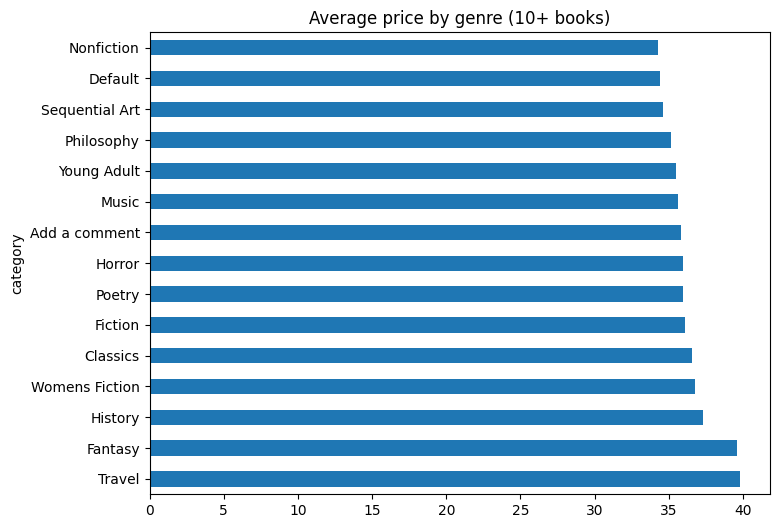

In [31]:
by_genre["avg_price"].head(15).plot(
    kind="barh", figsize=(8, 6), title="Average price by genre (10+ books)");

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

full = pd.read_csv("books_full.csv")

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11


def export(df, name):
    """Save a chart-ready table into charts/ and hand it back."""
    path = CHARTS / f"{name}.csv"
    df.to_csv(path, index=False)          # index=False ALWAYS for Datawrapper
    print(f"saved {path}  ({df.shape[0]} rows x {df.shape[1]} cols)")
    return df


print(f"{len(full)} books loaded")

1000 books loaded


In [49]:
genre = (full.groupby("category")
             .agg(**{"Books": ("title", "count"),
                     "Average price": ("price", "mean"),
                     "Average rating": ("rating", "mean")})
             .reset_index()
             .rename(columns={"category": "Genre"}))

genre = genre[genre["Books"] >= 10]
genre["Average price"] = genre["Average price"].round(2)
genre["Average rating"] = genre["Average rating"].round(2)
genre = genre.sort_values("Average price", ascending=False)

genre.to_csv("project3_genre_summary.csv", index=False)
genre

,Genre,Books,Average price,Average rating
47,Travel,11,39.79,2.73
16,Fantasy,48,39.59,3.08
22,History,18,37.29,2.94
48,Womens Fiction,17,36.79,3.12
10,Classics,19,36.55,2.47
17,Fiction,65,36.07,3.18
33,Poetry,19,35.97,3.53
23,Horror,17,35.95,2.71
1,Add a comment,67,35.80,2.76
25,Music,13,35.64,3.15


In [40]:
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.axisbelow"] = True

BLUE = "#2b7bba"

print(f"{len(full)} books loaded")

1000 books loaded


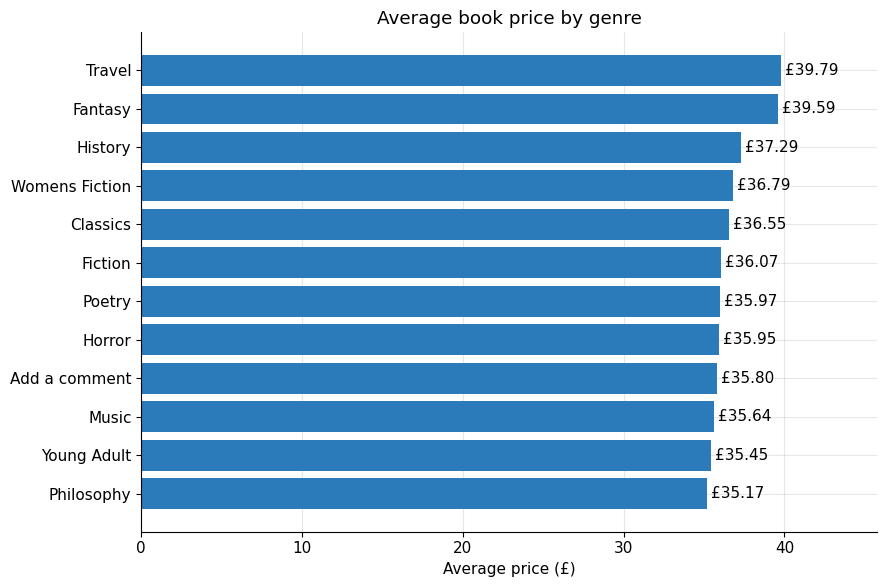

In [50]:
top = genre.head(12).sort_values("Average price")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top["Genre"], top["Average price"], color=BLUE)
ax.bar_label(bars, fmt="£%.2f", padding=3)
ax.set_xlim(0, top["Average price"].max() * 1.15)
ax.set_xlabel("Average price (£)")
ax.set_title("Average book price by genre")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
genre = (full.groupby("category")
             .agg(**{"Books": ("title", "count"),
                     "Average price": ("price", "mean"),
                     "Average rating": ("rating", "mean")})
             .reset_index()
             .rename(columns={"category": "Genre"}))

genre = genre[genre["Books"] >= 10]
genre["Average price"] = genre["Average price"].round(2)
genre["Average rating"] = genre["Average rating"].round(2)
genre = genre.sort_values("Average price", ascending=False)

genre.to_csv("project3_genre_summary.csv", index=False)
genre

,Genre,Books,Average price,Average rating
47,Travel,11,39.79,2.73
16,Fantasy,48,39.59,3.08
22,History,18,37.29,2.94
48,Womens Fiction,17,36.79,3.12
10,Classics,19,36.55,2.47
17,Fiction,65,36.07,3.18
33,Poetry,19,35.97,3.53
23,Horror,17,35.95,2.71
1,Add a comment,67,35.80,2.76
25,Music,13,35.64,3.15


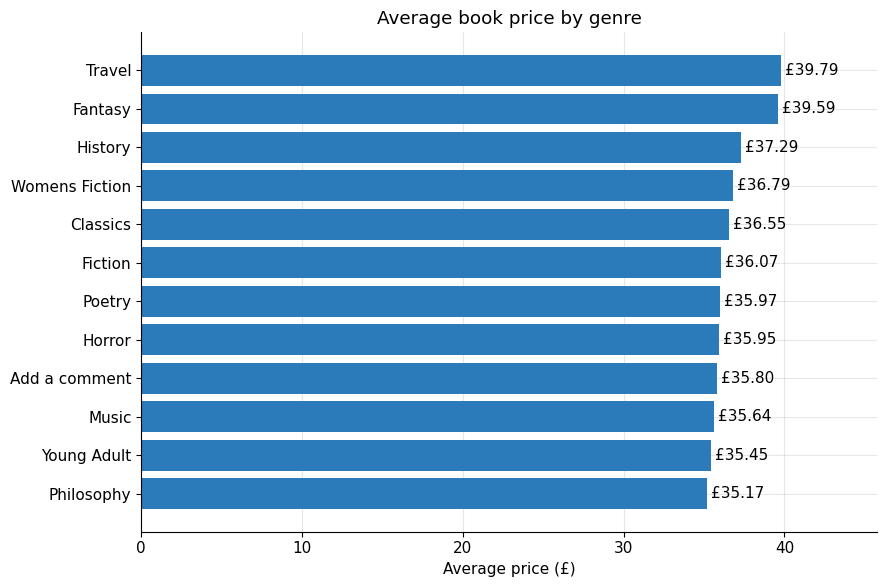

In [43]:
top = genre.head(12).sort_values("Average price")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top["Genre"], top["Average price"], color=BLUE)
ax.bar_label(bars, fmt="£%.2f", padding=3)
ax.set_xlim(0, top["Average price"].max() * 1.15)
ax.set_xlabel("Average price (£)")
ax.set_title("Average book price by genre")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

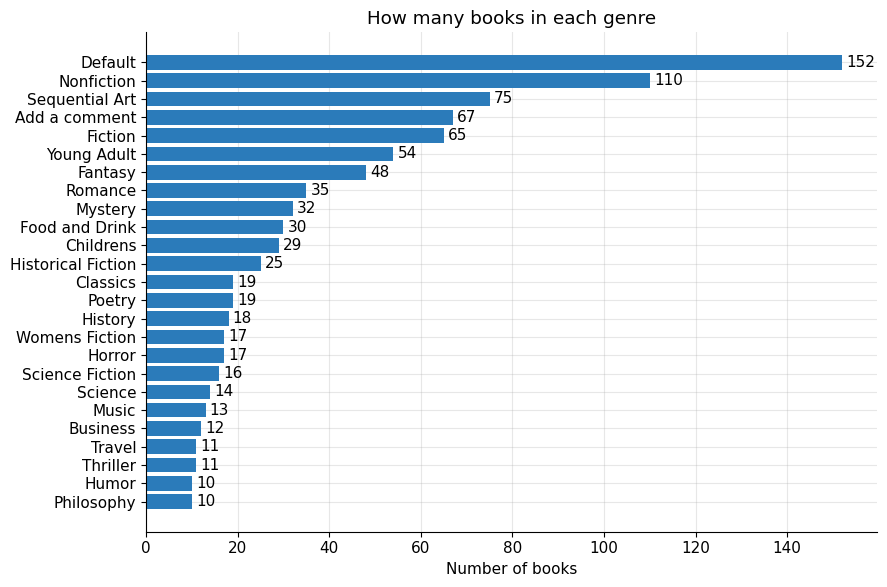

In [44]:
cnt = genre.sort_values("Books")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(cnt["Genre"], cnt["Books"], color=BLUE)
ax.bar_label(bars, padding=3)
ax.set_xlabel("Number of books")
ax.set_title("How many books in each genre")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

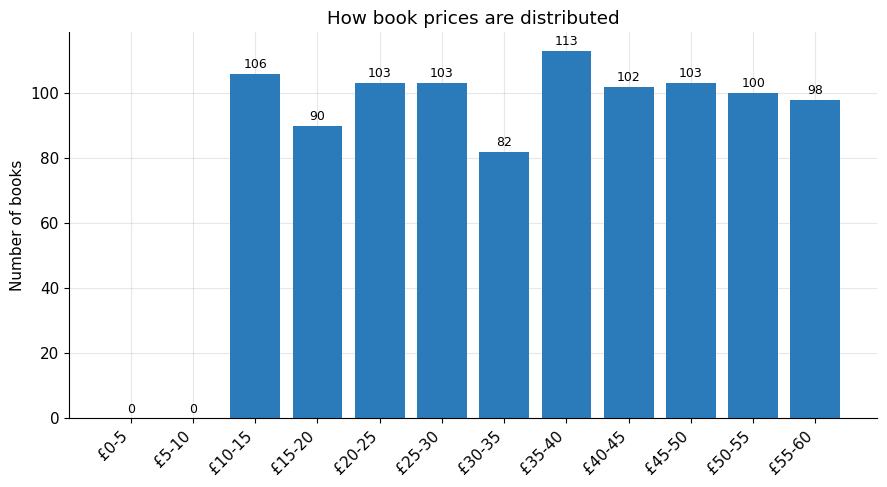

In [52]:
bins = range(0, 65, 5)
counts, edges = np.histogram(full["price"], bins=bins)

hist = pd.DataFrame({
    "Price range": [f"£{int(edges[i])}-{int(edges[i+1])}" for i in range(len(counts))],
    "Books": counts,
})

hist.to_csv("project3_price_distribution.csv", index=False)

fig, ax = plt.subplots()
bars = ax.bar(hist["Price range"], hist["Books"], color=BLUE)
ax.bar_label(bars, padding=2, fontsize=9)
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("Number of books")
ax.set_title("How book prices are distributed")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
genre[["Genre", "Average price"]].sort_values("Average price", ascending=False) \
     .to_csv("project3_avg_price_by_genre.csv", index=False)

genre[["Genre", "Books"]].sort_values("Books", ascending=False) \
     .to_csv("project3_books_per_genre.csv", index=False)


NameError: name 'glob' is not defined